 # Customer Churn

 Beta Bank customers are leaving: little by little, chipping away every month. The bankers figured out it’s cheaper to save the existing customers than to attract new ones.



 We need to predict whether the customer will leave the bank soon. You have the data on clients’ past behavior and termination of contracts with the bank.



 Build a model with the maximum possible *F1* score. To pass the project, you need an *F1* score of at least 0.59. Check the *F1* for the test set.



 Additionally, measure the *AUC-ROC* metric and compare it with the *F1*.



 Data source: [https://www.kaggle.com/barelydedicated/bank-customer-churn-modeling](https://www.kaggle.com/barelydedicated/bank-customer-churn-modeling)

 # 1. Data preparation

 ### Data research

In [9]:
#Import libraries and data
import pandas as pd
pd.set_option('display.max_columns', None)

#data = pd.read_csv('https://code.s3.yandex.net/datasets/Churn.csv')
data = pd.read_csv('Churn.csv')


data.info()
print()
data.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB



,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0


In [10]:
# %%
data.dtypes


RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure             float64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [11]:
# %%
types = pd.DataFrame(data.dtypes)
list(types[types[0] == 'object'].index)


['Surname', 'Geography', 'Gender']

In [12]:
# %%
var_non_informative = ['RowNumber', 'CustomerId', 'Surname']
var_numeric = ['CreditScore', 'Age', 'Tenure', 'Balance', 
               'NumOfProducts', 'HasCrCard', 'IsActiveMember', 
               'EstimatedSalary']
var_categorical = ['Geography', 'Gender']


 ### Removing abundant features

In [13]:
# %%
data = data.drop(var_non_informative, axis=1) 


 ### Encoding categorical features

In [14]:
# %%
data = pd.get_dummies(data, drop_first=True, columns=var_categorical)


 ### Filling in the missing values

In [15]:
# %%
data['Tenure'] = data['Tenure'].fillna(value=data['Tenure'].median())


 ### Splitting into samples

In [16]:
# %%
from sklearn.model_selection import train_test_split

train_valid, test = train_test_split(data, test_size=0.2)
train, valid = train_test_split(train_valid, test_size=0.25)

features_train = train.drop(['Exited'], axis=1)
target_train = train['Exited']
features_valid = valid.drop(['Exited'], axis=1)
target_valid = valid['Exited']
features_test = test.drop(['Exited'], axis=1)
target_test = test['Exited']

print(features_train.shape)
print(features_valid.shape)
print(features_test.shape)


(6000, 11)
(2000, 11)
(2000, 11)


 ### Scaling

In [17]:
# %%
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features_train[var_numeric] = scaler.fit_transform(features_train[var_numeric])
features_valid[var_numeric] = scaler.transform(features_valid[var_numeric])
features_test[var_numeric] = scaler.transform(features_test[var_numeric])


 # 2. Task research

 ### Class balance

Exited
0    0.796167
1    0.203833
Name: proportion, dtype: float64


<Axes: xlabel='Exited'>

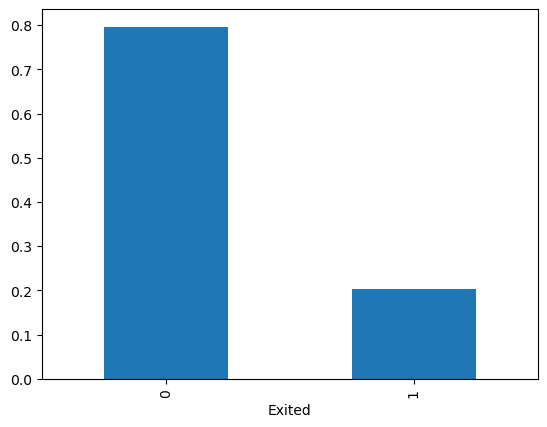

In [36]:
# %%
print(target_train.value_counts(normalize=True))
target_train.value_counts(normalize=True).plot(kind='bar')


 **Conclusion:** there is class imbalance

 ### Quality of unadjusted models

In [19]:
# %%
from sklearn.metrics import f1_score, roc_auc_score


In [20]:
# %%
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=12345)
    
model.fit(features_train, target_train)
predicted_valid = model.predict(features_valid)
probablities_valid = model.predict_proba(features_valid)[:, 1]

print('F1 =', f1_score(target_valid, predicted_valid))
print('AUC-ROC =', roc_auc_score(target_valid, probablities_valid))


F1 = 0.32809773123909247
AUC-ROC = 0.7582742669722958


In [21]:
# %%
from sklearn.tree import DecisionTreeClassifier

for depth in [1, 2, 4, 6, 8, None]:
    model = DecisionTreeClassifier(random_state=12345, max_depth=depth)

    model.fit(features_train, target_train)
    predicted_valid = model.predict(features_valid)
    probablities_valid = model.predict_proba(features_valid)[:, 1]

    print("max_depth =", depth)
    print('  F1 =', f1_score(target_valid, predicted_valid))
    print('  AUC-ROC =', roc_auc_score(target_valid, probablities_valid))


max_depth = 1
  F1 = 0.0
  AUC-ROC = 0.6567566864039419
max_depth = 2
  F1 = 0.4873417721518987
  AUC-ROC = 0.7128234103377998
max_depth = 4
  F1 = 0.49337748344370863
  AUC-ROC = 0.7999422734462446
max_depth = 6
  F1 = 0.5187601957585645
  AUC-ROC = 0.8227978544708985
max_depth = 8
  F1 = 0.5580029368575624
  AUC-ROC = 0.8062064466932792
max_depth = None
  F1 = 0.49941383352872215
  AUC-ROC = 0.6870661895421534


In [22]:
# %%
from sklearn.ensemble import RandomForestClassifier

for estim in range(10, 101, 10):
    model = RandomForestClassifier(random_state=12345, n_estimators=estim)

    model.fit(features_train, target_train)
    predicted_valid = model.predict(features_valid)
    probablities_valid = model.predict_proba(features_valid)[:, 1]

    print("n_estimators =", estim)
    print('  F1 =', f1_score(target_valid, predicted_valid))
    print('  AUC-ROC =', roc_auc_score(target_valid, probablities_valid))


n_estimators = 10
  F1 = 0.5538461538461539
  AUC-ROC = 0.8061926658183772
n_estimators = 20
  F1 = 0.5577812018489985
  AUC-ROC = 0.8240098058580968
n_estimators = 30
  F1 = 0.5591397849462365
  AUC-ROC = 0.8295512487769474
n_estimators = 40
  F1 = 0.5608628659476117
  AUC-ROC = 0.8353399818398692
n_estimators = 50
  F1 = 0.5519379844961241
  AUC-ROC = 0.8367586463505947
n_estimators = 60
  F1 = 0.5591397849462365
  AUC-ROC = 0.8371452764520065
n_estimators = 70
  F1 = 0.5557251908396946
  AUC-ROC = 0.8380234244249165
n_estimators = 80
  F1 = 0.5487804878048781
  AUC-ROC = 0.8388364960441232
n_estimators = 90
  F1 = 0.551829268292683
  AUC-ROC = 0.8390776613549051
n_estimators = 100
  F1 = 0.5504587155963303
  AUC-ROC = 0.8400377289730645


 **Conclusion:** neither of models reaches required quality.

 # 3. Fixing imbalance

 ### Class weight adjustment

In [23]:
# %%
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=12345, class_weight='balanced')
    
model.fit(features_train, target_train)
predicted_valid = model.predict(features_valid)
probablities_valid = model.predict_proba(features_valid)[:, 1]

print('F1 =', f1_score(target_valid, predicted_valid))
print('AUC-ROC =', roc_auc_score(target_valid, probablities_valid))


F1 = 0.49029982363315694
AUC-ROC = 0.761521959824156


In [24]:
# %%
from sklearn.tree import DecisionTreeClassifier

for depth in [1, 2, 4, 6, 8, None]:
    model = DecisionTreeClassifier(random_state=12345, 
                                   max_depth=depth, class_weight='balanced')

    model.fit(features_train, target_train)
    predicted_valid = model.predict(features_valid)
    probablities_valid = model.predict_proba(features_valid)[:, 1]

    print("max_depth =", depth)
    print('  F1 =', f1_score(target_valid, predicted_valid))
    print('  AUC-ROC =', roc_auc_score(target_valid, probablities_valid))


max_depth = 1
  F1 = 0.4613778705636743
  AUC-ROC = 0.6662762085444487
max_depth = 2
  F1 = 0.5
  AUC-ROC = 0.7206494160737063
max_depth = 4
  F1 = 0.5590778097982709
  AUC-ROC = 0.8084190427191811
max_depth = 6
  F1 = 0.576171875
  AUC-ROC = 0.8257224623667274
max_depth = 8
  F1 = 0.5579053373615307
  AUC-ROC = 0.8026364344895488
max_depth = None
  F1 = 0.5102781136638452
  AUC-ROC = 0.6921850189640151


In [25]:
# %%
from sklearn.ensemble import RandomForestClassifier

for estim in range(10, 101, 10):
    model = RandomForestClassifier(random_state=12345, 
                                   n_estimators=estim, class_weight='balanced')

    model.fit(features_train, target_train)
    predicted_valid = model.predict(features_valid)
    probablities_valid = model.predict_proba(features_valid)[:, 1]

    print("n_estimators =", estim)
    print('  F1 =', f1_score(target_valid, predicted_valid))
    print('  AUC-ROC =', roc_auc_score(target_valid, probablities_valid))


n_estimators = 10
  F1 = 0.5420560747663551
  AUC-ROC = 0.8119584307564629
n_estimators = 20
  F1 = 0.5419968304278923
  AUC-ROC = 0.8279388864134356
n_estimators = 30
  F1 = 0.542319749216301
  AUC-ROC = 0.8329459376277601
n_estimators = 40
  F1 = 0.542319749216301
  AUC-ROC = 0.8359670116479018
n_estimators = 50
  F1 = 0.5420560747663551
  AUC-ROC = 0.8358621238778157
n_estimators = 60
  F1 = 0.5368916797488226
  AUC-ROC = 0.8381428586740656
n_estimators = 70
  F1 = 0.53125
  AUC-ROC = 0.8386198300665002
n_estimators = 80
  F1 = 0.5460218408736349
  AUC-ROC = 0.839222360541374
n_estimators = 90
  F1 = 0.5368916797488226
  AUC-ROC = 0.8386297829205962
n_estimators = 100
  F1 = 0.543171114599686
  AUC-ROC = 0.8403577515124511


 **Conclusion:** Class weighting helps some algorithms, but not enough weight adjustment helps some of the algorithms but it is not enough

 ### Upsampling

In [26]:
# %%
from sklearn.utils import shuffle

def upsample(features, target, repeat):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_upsampled = pd.concat([features_zeros] + [features_ones] * repeat)
    target_upsampled = pd.concat([target_zeros] + [target_ones] * repeat)
    
    features_upsampled, target_upsampled = shuffle(
        features_upsampled, target_upsampled, random_state=12345)
    
    return features_upsampled, target_upsampled

features_upsampled, target_upsampled = upsample(features_train, target_train, 3)


In [27]:
# %%
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=12345)
    
model.fit(features_upsampled, target_upsampled)
predicted_valid = model.predict(features_valid)
probablities_valid = model.predict_proba(features_valid)[:, 1]

print('F1 =', f1_score(target_valid, predicted_valid))
print('AUC-ROC =', roc_auc_score(target_valid, probablities_valid))


F1 = 0.48925281473899696
AUC-ROC = 0.7611284392852932


In [28]:
# %%
from sklearn.tree import DecisionTreeClassifier

for depth in [1, 2, 4, 6, 8, None]:
    model = DecisionTreeClassifier(random_state=12345, max_depth=depth)

    model.fit(features_upsampled, target_upsampled)
    predicted_valid = model.predict(features_valid)
    probablities_valid = model.predict_proba(features_valid)[:, 1]

    print("max_depth =", depth)
    print('  F1 =', f1_score(target_valid, predicted_valid))
    print('  AUC-ROC =', roc_auc_score(target_valid, probablities_valid))


max_depth = 1
  F1 = 0.4613778705636743
  AUC-ROC = 0.6662762085444487
max_depth = 2
  F1 = 0.5
  AUC-ROC = 0.7206494160737063
max_depth = 4
  F1 = 0.5590778097982709
  AUC-ROC = 0.8084190427191811
max_depth = 6
  F1 = 0.5738396624472574
  AUC-ROC = 0.8192852625792593
max_depth = 8
  F1 = 0.5591623036649215
  AUC-ROC = 0.7980060605225402
max_depth = None
  F1 = 0.5072115384615384
  AUC-ROC = 0.690611702412725


In [29]:
# %%
from sklearn.ensemble import RandomForestClassifier

for estim in range(10, 101, 10):
    model = RandomForestClassifier(random_state=12345, n_estimators=estim)

    model.fit(features_upsampled, target_upsampled)
    predicted_valid = model.predict(features_valid)
    probablities_valid = model.predict_proba(features_valid)[:, 1]

    print("n_estimators =", estim)
    print('  F1 =', f1_score(target_valid, predicted_valid))
    print('  AUC-ROC =', roc_auc_score(target_valid, probablities_valid))


n_estimators = 10
  F1 = 0.556786703601108
  AUC-ROC = 0.819389384745184
n_estimators = 20
  F1 = 0.5833333333333334
  AUC-ROC = 0.8305786895612935
n_estimators = 30
  F1 = 0.5846994535519126
  AUC-ROC = 0.8350942229041203
n_estimators = 40
  F1 = 0.5906593406593407
  AUC-ROC = 0.8360627121680532
n_estimators = 50
  F1 = 0.5945205479452055
  AUC-ROC = 0.8389375557934033
n_estimators = 60
  F1 = 0.5904761904761905
  AUC-ROC = 0.8402635822006219
n_estimators = 70
  F1 = 0.5991792065663475
  AUC-ROC = 0.8420864857084671
n_estimators = 80
  F1 = 0.6008230452674898
  AUC-ROC = 0.8425221144761965
n_estimators = 90
  F1 = 0.6065573770491803
  AUC-ROC = 0.8430411940974982
n_estimators = 100
  F1 = 0.5986206896551725
  AUC-ROC = 0.8436575054472737


 ### Downsampling

In [30]:
# %%
def downsample(features, target, fraction):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_downsampled = pd.concat(
        [features_zeros.sample(frac=fraction, random_state=12345)] + [features_ones])
    target_downsampled = pd.concat(
        [target_zeros.sample(frac=fraction, random_state=12345)] + [target_ones])
    
    features_downsampled, target_downsampled = shuffle(
        features_downsampled, target_downsampled, random_state=12345)
    
    return features_downsampled, target_downsampled

features_downsampled, target_downsampled = downsample(features_train, target_train, 0.3)


In [31]:
# %%
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=12345)
    
model.fit(features_downsampled, target_downsampled)
predicted_valid = model.predict(features_valid)
probablities_valid = model.predict_proba(features_valid)[:, 1]

print('F1 =', f1_score(target_valid, predicted_valid))
print('AUC-ROC =', roc_auc_score(target_valid, probablities_valid))


F1 = 0.49759846301633043
AUC-ROC = 0.7597411645451775


In [32]:
# %%
from sklearn.tree import DecisionTreeClassifier

for depth in [1, 2, 4, 6, 8, None]:
    model = DecisionTreeClassifier(random_state=12345, max_depth=depth)

    model.fit(features_downsampled, target_downsampled)
    predicted_valid = model.predict(features_valid)
    probablities_valid = model.predict_proba(features_valid)[:, 1]

    print("max_depth =", depth)
    print('  F1 =', f1_score(target_valid, predicted_valid))
    print('  AUC-ROC =', roc_auc_score(target_valid, probablities_valid))


max_depth = 1
  F1 = 0.4533333333333333
  AUC-ROC = 0.658496139058215
max_depth = 2
  F1 = 0.4994663820704376
  AUC-ROC = 0.7138631007887253
max_depth = 4
  F1 = 0.522911051212938
  AUC-ROC = 0.7938909381560272
max_depth = 6
  F1 = 0.5529622980251346
  AUC-ROC = 0.8223637569114918
max_depth = 8
  F1 = 0.5518518518518518
  AUC-ROC = 0.8085254616975895
max_depth = None
  F1 = 0.5114155251141552
  AUC-ROC = 0.7135086260620844


In [33]:
# %%
from sklearn.ensemble import RandomForestClassifier

for estim in range(10, 101, 10):
    model = RandomForestClassifier(random_state=12345, n_estimators=estim)

    model.fit(features_downsampled, target_downsampled)
    predicted_valid = model.predict(features_valid)
    probablities_valid = model.predict_proba(features_valid)[:, 1]

    print("n_estimators =", estim)
    print('  F1 =', f1_score(target_valid, predicted_valid))
    print('  AUC-ROC =', roc_auc_score(target_valid, probablities_valid))


n_estimators = 10
  F1 = 0.560687432867884
  AUC-ROC = 0.8090070267149916
n_estimators = 20
  F1 = 0.5828092243186582
  AUC-ROC = 0.8278064368935458
n_estimators = 30
  F1 = 0.5919003115264797
  AUC-ROC = 0.8359930421893831
n_estimators = 40
  F1 = 0.6012526096033403
  AUC-ROC = 0.8386856720243646
n_estimators = 50
  F1 = 0.5981308411214953
  AUC-ROC = 0.8394007463109364
n_estimators = 60
  F1 = 0.6012396694214877
  AUC-ROC = 0.8398708272659204
n_estimators = 70
  F1 = 0.5882352941176471
  AUC-ROC = 0.8413002102349026
n_estimators = 80
  F1 = 0.5956566701137539
  AUC-ROC = 0.8421071570208198
n_estimators = 90
  F1 = 0.5957011258955988
  AUC-ROC = 0.8424394292267856
n_estimators = 100
  F1 = 0.5952626158599382
  AUC-ROC = 0.8430603342015285


 ### Findings

 1) The best model: upsampling + RandomForest(n_estimators=100)



 2) F1 and AUC-ROC in general grow simultaneously, but sometimes their maxima don't match (for example, see RandomForest with weight adjustment)

 # 4. Model testing

 ### Training using complete data

In [34]:
# %%
features_full_train = pd.concat([features_train, features_valid])
target_full_train = pd.concat([target_train, target_valid])

features_upsampled, target_upsampled = upsample(features_full_train, target_full_train, 3)

model = RandomForestClassifier(random_state=12345, n_estimators=100)
model.fit(features_upsampled, target_upsampled)


RandomForestClassifier(random_state=12345)

In [35]:
# %%
predicted_test = model.predict(features_test)
probablities_test = model.predict_proba(features_test)[:, 1]

print('F1 =', f1_score(target_test, predicted_test))
print('AUC-ROC =', roc_auc_score(target_test, probablities_test))


F1 = 0.6097560975609756
AUC-ROC = 0.8524800688636106
